# CSC2042S — Assignment 2: Multinomial Logistic Regression for MasakhaNEWS Topic Classification

This notebook implements and evaluates a multinomial logistic regression model (in PyTorch, with an object-oriented design) for
news-topic classification on the **MasakhaNEWS** dataset, for three languages: **English (eng)**, **isiXhosa (xho)** and **chiShona (sna)**.

**Contents**
1. Data processing (cleaning, tokenisation, feature extraction)
2. `MultinomialLogisticRegression` model (PyTorch `nn.Module`)
3. Training & evaluation pipeline (pilot run on English)
4. Baseline experiments (all languages × Bag-of-Words / TF-IDF)
5. Hyperparameter tuning (learning rate, batch size, vocabulary size, min. frequency)
6. Weight analysis (English)
7. isiXhosa class-imbalance experiments (upsampling / downsampling)
8. Bilingual training (isiXhosa+chiShona vs. isiXhosa+English)
9. Final isiXhosa results summary




## Imports and Setup

Importing all required libraries for data handling, feature extraction, model training, and evaluation.


In [ ]:
# Core
import re
import string
import random
import copy
import numpy as np
import pandas as pd
from itertools import product

# Data splitting & feature extraction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics
from sklearn.metrics import (precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# PyTorch
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# Plotting (for validation loss curves, confusion matrices)
import matplotlib.pyplot as plt


## 1. Data Loading

Loading the MasakhaNEWS dataset for the three target languages: English, isiXhosa, and chiShona.


In [2]:
DATA_PATH = "news-dataset"


def load_language(language):
    train = pd.read_csv(f"{DATA_PATH}/{language}/train.tsv", sep="\t")
    dev   = pd.read_csv(f"{DATA_PATH}/{language}/dev.tsv",   sep="\t")
    test  = pd.read_csv(f"{DATA_PATH}/{language}/test.tsv",  sep="\t")
    return train, dev, test

eng_train, eng_dev, eng_test = load_language("eng")
xho_train, xho_dev, xho_test = load_language("xho")
sna_train, sna_dev, sna_test = load_language("sna")

print("Data loaded successfully!")
print("English : train={}, dev={}, test={}".format(len(eng_train), len(eng_dev), len(eng_test)))
print("isiXhosa: train={}, dev={}, test={}".format(len(xho_train), len(xho_dev), len(xho_test)))
print("chiShona: train={}, dev={}, test={}".format(len(sna_train), len(sna_dev), len(sna_test)))
print()
print("English classes :", sorted(eng_train["category"].unique()))
print("isiXhosa classes:", sorted(xho_train["category"].unique()))
print("chiShona classes:", sorted(sna_train["category"].unique()))


Data loaded successfully!
English : train=3309, dev=472, test=948
isiXhosa: train=1032, dev=147, test=297
chiShona: train=1288, dev=185, test=369

English classes : ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
isiXhosa classes: ['business', 'entertainment', 'health', 'politics', 'sports']
chiShona classes: ['business', 'health', 'politics', 'sports']


**Note on dataset coverage.** As the assignment brief notes, not every language covers all seven MasakhaNEWS
categories. English covers 6 (no *religion*), isiXhosa covers 5 (no *religion* or *technology*), and chiShona
covers only 4 (*business*, *health*, *politics*, *sports*). This means the number of output classes — and therefore
the shape of the final softmax layer — differs across the three `MultinomialLogisticRegression` models we train below.


### 1.1 Text Cleaning & Label Encoding

**Cleaning decisions (and why).** We apply a deliberately simple, language-agnostic cleaning step:
- **Lowercasing** — collapses case variants of the same word (e.g. "Business" / "business") into one vocabulary entry,
  which matters most for English where sentence-initial capitalisation is common; it has little effect on isiXhosa/chiShona,
  which don't capitalise as heavily, but does no harm.
- **Punctuation stripped to whitespace** (`[^\w\s]` → space) rather than deleted outright — this avoids accidentally
  gluing two words together (e.g. "Sethi cannot understand why it is taking so long for the Post Office to pay him
  compensation." → "...compensation " + next sentence, not "compensationBaljit").
- **Whitespace collapsing** — tidies up the multiple spaces created by the punctuation step.
- We deliberately do **not** apply stemming/lemmatisation or stop-word removal: MasakhaNEWS covers under-resourced
  languages (isiXhosa, chiShona) for which robust stemmers/stop-word lists are not readily available in scikit-learn,
  so applying them only to English would make the pipeline inconsistent across languages. Basic whitespace/regex tokenisation
  (via scikit-learn's default `CountVectorizer`/`TfidfVectorizer` analyzer) is therefore used uniformly for all three languages.
  The trade-off is a larger, noisier vocabulary (e.g. "wins"/"winning"/"win" all remain separate features), which we
  partially control for later via the `max_features` and `min_df` hyperparameters (Task 5).

Labels are encoded with `LabelEncoder`, **fit only on the training set** and reused (via `.transform`) on dev/test, to
avoid leaking information about the label space and keep an identical index→class mapping across splits.


In [3]:
# 1. Create full_text
def create_full_text(df):
    return df["headline"].fillna("") + " " + df["text"].fillna("")


eng_train["full_text"] = create_full_text(eng_train)
eng_dev["full_text"]   = create_full_text(eng_dev)
eng_test["full_text"]  = create_full_text(eng_test)


# 2. Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


eng_train_text = eng_train["full_text"].apply(clean_text)
eng_dev_text   = eng_dev["full_text"].apply(clean_text)
eng_test_text  = eng_test["full_text"].apply(clean_text)


# 3. Encode the category labels
LABEL_COL = "category"

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(eng_train[LABEL_COL])
y_dev   = label_encoder.transform(eng_dev[LABEL_COL])
y_test  = label_encoder.transform(eng_test[LABEL_COL])


# Check what happened
print("Classes:", list(label_encoder.classes_))
print("Number of classes:", len(label_encoder.classes_))
print("\nExample cleaned text:\n", eng_train_text.iloc[0][:200], "...")


Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Number of classes: 6

Example cleaned text:
 we haven t had a single penny from the post office baljit sethi cannot understand why it is taking so long for the post office to pay him compensation it doesn t seem like they re interested in doing  ...


### 1.2 Feature Extraction — Bag-of-Words

Converting the cleaned text into numerical vectors using a `CountVectorizer`, as a first pilot on English before we
wrap everything into a reusable function (Section 1.3).


In [4]:
# 4. Feature extraction (start with Bag-of-Words)
vectorizer = CountVectorizer(
    max_features=5000,
    min_df=3
)

X_train = vectorizer.fit_transform(eng_train_text)
X_dev   = vectorizer.transform(eng_dev_text)
X_test  = vectorizer.transform(eng_test_text)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("X_train shape:", X_train.shape)

# 5. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_dev_tensor   = torch.tensor(X_dev.toarray(),   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.toarray(),  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_dev_tensor   = torch.tensor(y_dev,   dtype=torch.long)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

print("\nTensors ready!")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)


Vocabulary size: 5000
X_train shape: (3309, 5000)

Tensors ready!
X_train_tensor: torch.Size([3309, 5000])
y_train_tensor: torch.Size([3309])


### 1.3 Reusable Data-Preparation Pipeline

Wrapping the full data-preparation pipeline (text cleaning, vectorisation, and tensor conversion) into a single reusable
`prepare_language` function, parameterised by `max_features`, `min_df` and `vectorizer_type` (`"count"` or `"tfidf"`) so
it can be re-used across languages, feature-extraction methods, and hyperparameter settings later in the notebook.


In [5]:
def prepare_language(
    train_df,
    dev_df,
    test_df,
    max_features=5000,
    min_df=3,
    vectorizer_type="count"
):
    # 1. Create and clean full text
    train_text = (
        train_df["headline"].fillna("") + " " +
        train_df["text"].fillna("")
    ).apply(clean_text)

    dev_text = (
        dev_df["headline"].fillna("") + " " +
        dev_df["text"].fillna("")
    ).apply(clean_text)

    test_text = (
        test_df["headline"].fillna("") + " " +
        test_df["text"].fillna("")
    ).apply(clean_text)

    # 2. Encode labels
    le = LabelEncoder()

    y_train = le.fit_transform(train_df["category"])
    y_dev   = le.transform(dev_df["category"])
    y_test  = le.transform(test_df["category"])

    # 3. Choose feature extractor
    if vectorizer_type == "count":
        vectorizer = CountVectorizer(
            max_features=max_features,
            min_df=min_df
        )
    elif vectorizer_type == "tfidf":
        vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=min_df
        )
    else:
        raise ValueError(
            "vectorizer_type must be 'count' or 'tfidf'"
        )

    # 4. Fit only on training data
    X_train = vectorizer.fit_transform(train_text)

    # Use the same vocabulary for dev and test
    X_dev = vectorizer.transform(dev_text)
    X_test = vectorizer.transform(test_text)

    # 5. Convert features to PyTorch tensors
    X_train_t = torch.tensor(
        X_train.toarray(), dtype=torch.float32
    )
    X_dev_t = torch.tensor(
        X_dev.toarray(), dtype=torch.float32
    )
    X_test_t = torch.tensor(
        X_test.toarray(), dtype=torch.float32
    )

    # 6. Convert labels to PyTorch tensors
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_dev_t   = torch.tensor(y_dev, dtype=torch.long)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    print(
        f"Prepared data -> features: {X_train_t.shape[1]}, "
        f"classes: {len(le.classes_)}"
    )
    print(f"Classes: {list(le.classes_)}")

    return {
        "X_train": X_train_t,
        "y_train": y_train_t,
        "X_dev": X_dev_t,
        "y_dev": y_dev_t,
        "X_test": X_test_t,
        "y_test": y_test_t,
        "vectorizer": vectorizer,
        "label_encoder": le,
        "num_classes": len(le.classes_),
        "input_dim": X_train_t.shape[1]
    }


## 2. Multinomial Logistic Regression Model

Implementation of the multinomial logistic regression model as a PyTorch `nn.Module`, with the three required methods:
`forward` (raw logits for a batch), `compute_probabilities` (softmax over the logits), and `predict` (argmax class index).


In [6]:
class MultinomialLogisticRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        """Process a batch of inputs during training (returns logits)."""
        return self.linear(x)

    def compute_probabilities(self, x):
        """Compute class probabilities for a batch of inputs."""
        logits = self.forward(x)
        return F.softmax(logits, dim=1)

    def predict(self, x):
        """Return the predicted class indices for a batch of inputs."""
        probs = self.compute_probabilities(x)
        return torch.argmax(probs, dim=1)


### 2.1 Sanity Check

Running a quick forward pass on an untrained model to confirm the output shape is correct.


In [7]:
input_dim = X_train_tensor.shape[1]
num_classes = len(label_encoder.classes_)

model = MultinomialLogisticRegression(input_dim, num_classes)

# Quick sanity check
with torch.no_grad():
    logits = model(X_train_tensor[:5])
    probs  = model.compute_probabilities(X_train_tensor[:5])
    preds  = model.predict(X_train_tensor[:5])

print("Logits shape:", logits.shape)
print("Probs shape:", probs.shape)
print("Probs sum to 1 (per row)?", torch.allclose(probs.sum(dim=1), torch.ones(5)))
print("Preds:", preds)


Logits shape: torch.Size([5, 6])
Probs shape: torch.Size([5, 6])
Probs sum to 1 (per row)? True
Preds: tensor([3, 3, 3, 3, 3])


## 3. Training & Evaluation Pipeline (Pilot Run — English)

### 3.1 Training Function

Defining the training loop: mini-batch gradient descent with cross-entropy loss, where the training data is
reshuffled every epoch (`shuffle=True` in the `DataLoader`). We use **early stopping on validation accuracy** as our
stopping criterion rather than a fixed epoch count: we track the best validation accuracy seen so far, checkpoint the
model's weights whenever it improves, and stop once `patience` consecutive epochs pass without improvement — this
lets each configuration train for as long as it keeps improving on held-out data without us having to hand-pick a
single epoch budget that suits every language/feature-extraction/hyperparameter combination equally well (English,
isiXhosa and chiShona differ enormously in size, so a "one size fits all" fixed epoch count would either under-train
the larger configurations or badly overfit the smaller ones). We finish by restoring the best-seen weights, so the
returned model is always the one that generalised best to the validation set, not simply the one at the final epoch.


In [8]:
def train_model(
    model,
    X_train, y_train,
    X_dev, y_dev,
    lr=0.01,
    batch_size=32,
    num_epochs=50,
    patience=5,
    verbose=True
):
    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Gradient descent optimizer
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr
    )

    # Mini-batch training data
    train_dataset = TensorDataset(X_train, y_train)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Track the best validation performance
    best_val_acc = 0.0
    best_model_state = None
    epochs_without_improvement = 0

    # Store results for analysis/plots
    train_losses = []
    val_accuracies = []

    # Training loop
    for epoch in range(num_epochs):

        # ---- Training ----
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            logits = model(X_batch)

            # Calculate cross-entropy loss
            loss = criterion(logits, y_batch)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            epoch_loss += loss.item()

        # Average loss for this epoch
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---- Validation ----
        model.eval()

        with torch.no_grad():
            val_preds = model.predict(X_dev)

            val_acc = (
                (val_preds == y_dev)
                .float()
                .mean()
                .item()
            )

        val_accuracies.append(val_acc)

        # Print progress
        if verbose:
            print(
                f"Epoch {epoch + 1:3d} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

        # ---- Early stopping ----
        if val_acc > best_val_acc:

            best_val_acc = val_acc

            # Make a deep copy of the best weights
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:

                if verbose:
                    print(
                        f"Early stopping at epoch {epoch + 1}"
                    )

                break

    # Restore the best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "train_losses": train_losses,
        "val_accuracies": val_accuracies,
        "best_val_acc": best_val_acc
    }


In [9]:
# Prepare English data with Bag-of-Words
eng_bow = prepare_language(
    eng_train, eng_dev, eng_test,
    max_features=5000,
    min_df=3,
    vectorizer_type="count"
)


Prepared data -> features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']


Epoch   1 | Train Loss: 34.8082 | Val Acc: 0.6589
Epoch   2 | Train Loss: 7.5360 | Val Acc: 0.5826
Epoch   3 | Train Loss: 6.7521 | Val Acc: 0.7881
Epoch   4 | Train Loss: 3.4728 | Val Acc: 0.7373
Epoch   5 | Train Loss: 4.3740 | Val Acc: 0.8030
Epoch   6 | Train Loss: 1.5107 | Val Acc: 0.8559
Epoch   7 | Train Loss: 1.1362 | Val Acc: 0.8475
Epoch   8 | Train Loss: 0.6370 | Val Acc: 0.8602
Epoch   9 | Train Loss: 0.7684 | Val Acc: 0.8538
Epoch  10 | Train Loss: 0.7667 | Val Acc: 0.8390
Epoch  11 | Train Loss: 0.3775 | Val Acc: 0.8602
Epoch  12 | Train Loss: 0.4079 | Val Acc: 0.8538
Epoch  13 | Train Loss: 0.3754 | Val Acc: 0.8665
Epoch  14 | Train Loss: 0.2556 | Val Acc: 0.8559
Epoch  15 | Train Loss: 0.4946 | Val Acc: 0.5699
Epoch  16 | Train Loss: 1.0179 | Val Acc: 0.8623
Epoch  17 | Train Loss: 0.1307 | Val Acc: 0.8750
Epoch  18 | Train Loss: 0.1717 | Val Acc: 0.7987
Epoch  19 | Train Loss: 0.2767 | Val Acc: 0.7733
Epoch  20 | Train Loss: 0.1406 | Val Acc: 0.8750
Epoch  21 | Train L

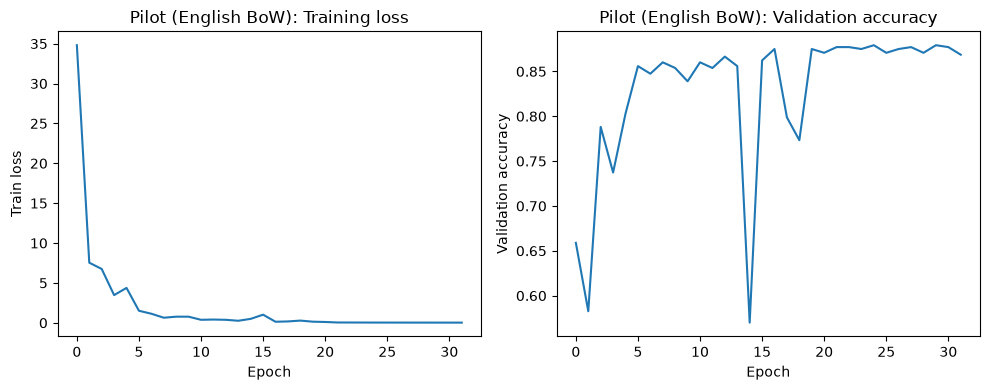

In [10]:
# Create model
model = MultinomialLogisticRegression(
    input_dim=eng_bow["input_dim"],
    num_classes=eng_bow["num_classes"]
)

# Train
history = train_model(
    model,
    eng_bow["X_train"], eng_bow["y_train"],
    eng_bow["X_dev"],   eng_bow["y_dev"],
    lr=0.1,
    batch_size=64,
    num_epochs=100,
    patience=7,
    verbose=True
)

print(f"\nBest validation accuracy: {history['best_val_acc']:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_losses"])
plt.xlabel("Epoch"); plt.ylabel("Train loss"); plt.title("Pilot (English BoW): Training loss")
plt.subplot(1, 2, 2)
plt.plot(history["val_accuracies"])
plt.xlabel("Epoch"); plt.ylabel("Validation accuracy"); plt.title("Pilot (English BoW): Validation accuracy")
plt.tight_layout()
plt.show()


### 3.2 Evaluation Function

Defining a reusable evaluation function that reports accuracy, precision/recall/F1 (micro and macro), and a confusion
matrix, then applying it to the pilot English model.


In [11]:
def evaluate_model(model, X, y, label_encoder, title="Test"):
    model.eval()
    with torch.no_grad():
        preds = model.predict(X).cpu().numpy()

    y_true = y.cpu().numpy()

    acc = accuracy_score(y_true, preds)
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(y_true, preds, average="micro", zero_division=0)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, preds, average="macro", zero_division=0)

    print(f"\n===== {title} Results =====")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Precision (micro): {precision_micro:.4f} | (macro): {precision_macro:.4f}")
    print(f"Recall    (micro): {recall_micro:.4f} | (macro): {recall_macro:.4f}")
    print(f"F1        (micro): {f1_micro:.4f} | (macro): {f1_macro:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {title}")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision_micro": precision_micro, "precision_macro": precision_macro,
        "recall_micro": recall_micro, "recall_macro": recall_macro,
        "f1_micro": f1_micro, "f1_macro": f1_macro
    }



===== English BoW Test Results =====
Accuracy       : 0.8882
Precision (micro): 0.8882 | (macro): 0.8837
Recall    (micro): 0.8882 | (macro): 0.8833
F1        (micro): 0.8882 | (macro): 0.8821


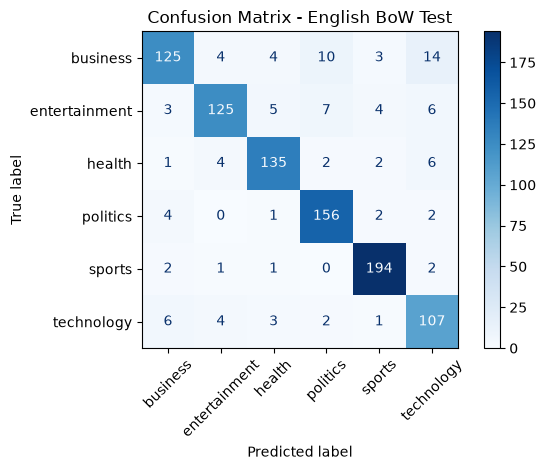

In [12]:
test_results = evaluate_model(
    model,
    eng_bow["X_test"],
    eng_bow["y_test"],
    eng_bow["label_encoder"],
    title="English BoW Test"
)


### 3.3 Reproducibility — Setting the Random Seed

Fixing all random seeds so subsequent experiments are reproducible.


In [13]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Random seed set to 42")


Random seed set to 42


## 4. Baseline Experiments

We train multinomial logistic regression models for all three languages (English, isiXhosa, and chiShona) using both
feature extraction methods, with a single "reasonable default" hyperparameter setting (`max_features=5000`, `min_df=3`,
`lr=0.1`, `batch_size=64`), before tuning hyperparameters properly in Section 5:

- Bag-of-Words (`CountVectorizer`)
- TF-IDF (`TfidfVectorizer`)



Training ENG with COUNT
Prepared data -> features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']

===== ENG COUNT Test Results =====
Accuracy       : 0.8914
Precision (micro): 0.8914 | (macro): 0.8878
Recall    (micro): 0.8914 | (macro): 0.8856
F1        (micro): 0.8914 | (macro): 0.8862


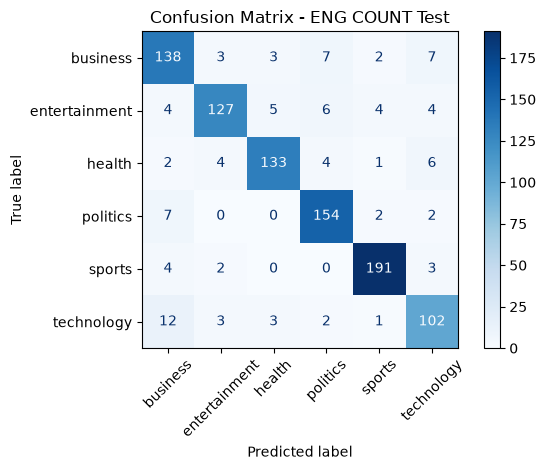


Training ENG with TFIDF
Prepared data -> features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']

===== ENG TFIDF Test Results =====
Accuracy       : 0.8449
Precision (micro): 0.8449 | (macro): 0.8521
Recall    (micro): 0.8449 | (macro): 0.8319
F1        (micro): 0.8449 | (macro): 0.8369


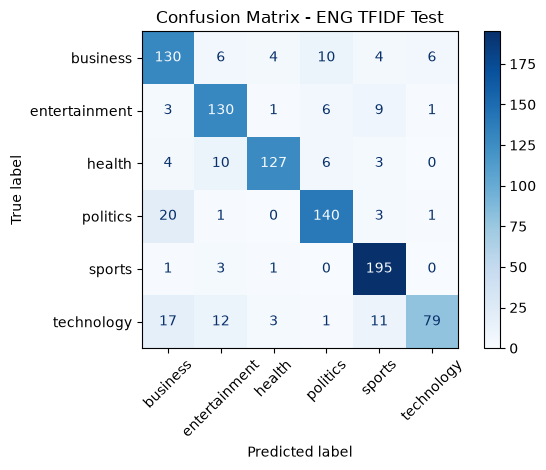


Training XHO with COUNT
Prepared data -> features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']

===== XHO COUNT Test Results =====
Accuracy       : 0.8822
Precision (micro): 0.8822 | (macro): 0.8676
Recall    (micro): 0.8822 | (macro): 0.7121
F1        (micro): 0.8822 | (macro): 0.7486


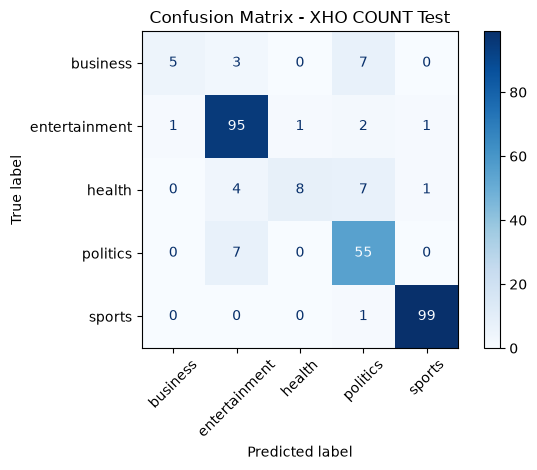


Training XHO with TFIDF
Prepared data -> features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']

===== XHO TFIDF Test Results =====
Accuracy       : 0.6667
Precision (micro): 0.6667 | (macro): 0.2828
Recall    (micro): 0.6667 | (macro): 0.3960
F1        (micro): 0.6667 | (macro): 0.3254


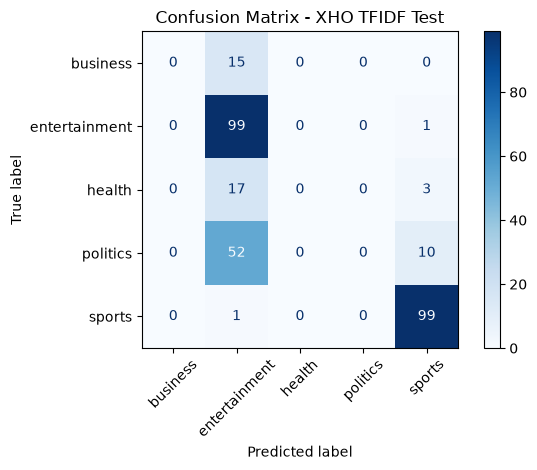


Training SNA with COUNT
Prepared data -> features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']

===== SNA COUNT Test Results =====
Accuracy       : 0.9295
Precision (micro): 0.9295 | (macro): 0.9340
Recall    (micro): 0.9295 | (macro): 0.9297
F1        (micro): 0.9295 | (macro): 0.9311


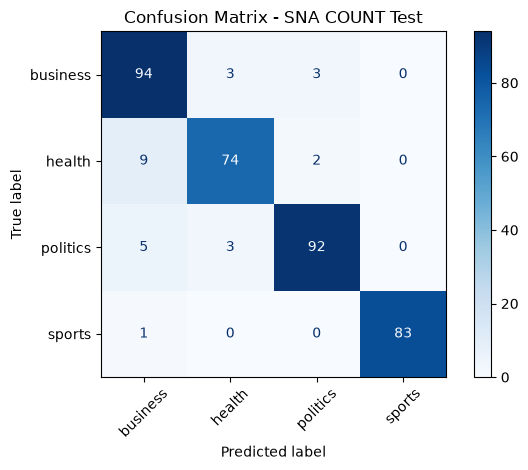


Training SNA with TFIDF
Prepared data -> features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']

===== SNA TFIDF Test Results =====
Accuracy       : 0.8943
Precision (micro): 0.8943 | (macro): 0.9122
Recall    (micro): 0.8943 | (macro): 0.8897
F1        (micro): 0.8943 | (macro): 0.8922


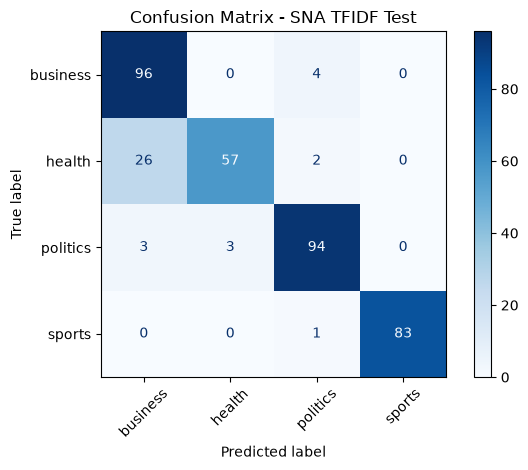



ALL baseline models finished


In [14]:
languages = {
    "eng": (eng_train, eng_dev, eng_test),
    "xho": (xho_train, xho_dev, xho_test),
    "sna": (sna_train, sna_dev, sna_test)
}

# Storing the results
baseline_results = {}

for lang_name, (train_df, dev_df, test_df) in languages.items():
    for vec_type in ["count", "tfidf"]:

        print(f"\n{'='*60}")
        print(f"Training {lang_name.upper()} with {vec_type.upper()}")
        print(f"{'='*60}")

        # 1. Prepare data
        data = prepare_language(
            train_df, dev_df, test_df,
            max_features=5000,
            min_df=3,
            vectorizer_type=vec_type
        )

        # 2. Create model
        model = MultinomialLogisticRegression(
            input_dim=data["input_dim"],
            num_classes=data["num_classes"]
        )

        # 3. Train
        history = train_model(
            model,
            data["X_train"], data["y_train"],
            data["X_dev"],   data["y_dev"],
            lr=0.1,
            batch_size=64,
            num_epochs=100,
            patience=7,
            verbose=False
        )

        # 4. Evaluate on test set
        test_results = evaluate_model(
            model,
            data["X_test"],
            data["y_test"],
            data["label_encoder"],
            title=f"{lang_name.upper()} {vec_type.upper()} Test"
        )

        # 5. Save everything
        baseline_results[f"{lang_name}_{vec_type}"] = {
            "data": data,
            "model": model,
            "history": history,
            "test_results": test_results
        }

print("\n\nALL baseline models finished")


### 4.1 Summary of Baseline Results

Creating a summary table of the baseline model results for each language and feature representation. The results stored
in `baseline_results` contain the validation and test metrics.


In [15]:
baseline_summary = []

for key, result in baseline_results.items():
    lang, vec_type = key.split("_")   # split "eng_count" -> ["eng", "count"]

    baseline_summary.append({
        "Language": lang,
        "Features": vec_type,
        "Val Accuracy": result["history"]["best_val_acc"],
        "Test Accuracy": result["test_results"]["accuracy"],
        "Test F1 (macro)": result["test_results"]["f1_macro"],
        "Test F1 (micro)": result["test_results"]["f1_micro"]
    })

baseline_summary = pd.DataFrame(baseline_summary)

display(
    baseline_summary
    .sort_values("Test Accuracy", ascending=False)
    .reset_index(drop=True)
)


,Language,Features,Val Accuracy,Test Accuracy,Test F1 (macro),Test F1 (micro)
0,sna,count,0.891892,0.929539,0.931128,0.929539
1,sna,tfidf,0.875676,0.894309,0.892219,0.894309
2,eng,count,0.875000,0.891350,0.886244,0.891350
3,xho,count,0.884354,0.882155,0.748595,0.882155
4,eng,tfidf,0.851695,0.844937,0.836875,0.844937
5,xho,tfidf,0.666667,0.666667,0.325352,0.666667


## 5. Hyperparameter Tuning

Tuning hyperparameters for each language and feature extraction method:
- **Learning rate**: `{0.01, 0.1, 0.3}`
- **Batch size**: `{32, 64}`
- **Vocabulary size** (`max_features`): `{3000, 5000, 8000}`
- **Minimum document frequency** (`min_df`): `{0, 3, 5, 10}` — note that scikit-learn requires `min_df=0.0` (a float)
  rather than the integer `0` to mean "no frequency cutoff", since an integer `min_df` must be `>= 1`.

This gives a grid of 3 × 2 × 3 × 4 = **72 configurations per (language, feature-extraction) combination**, i.e. 432



### 5.1 Full Hyperparameter Grid Search

Systematically searching for the best combination of hyperparameters for each language and feature extraction method.
Tuning is performed for every language (ENG, XHO, SNA) and both feature representations (CountVectorizer and
TfidfVectorizer). The best configuration is selected based on **validation accuracy**.



Tuning ENG - COUNT
Prepared data -> features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 5000, classes: 6
Classes: ['business', 'entertainm

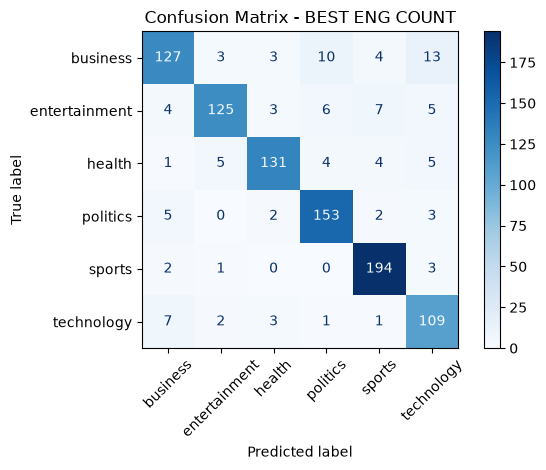


Best for eng + count:
Params: {'lr': 0.3, 'batch_size': 32, 'max_features': 8000, 'min_df': 10}
Val Acc: 0.8898 | Test Acc: 0.8850

Tuning ENG - TFIDF
Prepared data -> features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Prepared data -> features: 5000, classes: 6
Classes: ['business', 'enterta

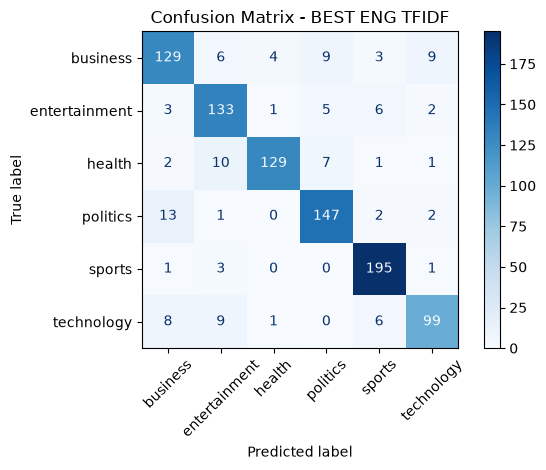


Best for eng + tfidf:
Params: {'lr': 0.3, 'batch_size': 32, 'max_features': 8000, 'min_df': 10}
Val Acc: 0.8708 | Test Acc: 0.8776

Tuning XHO - COUNT
Prepared data -> features: 3000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 2702, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 2702, classes: 5

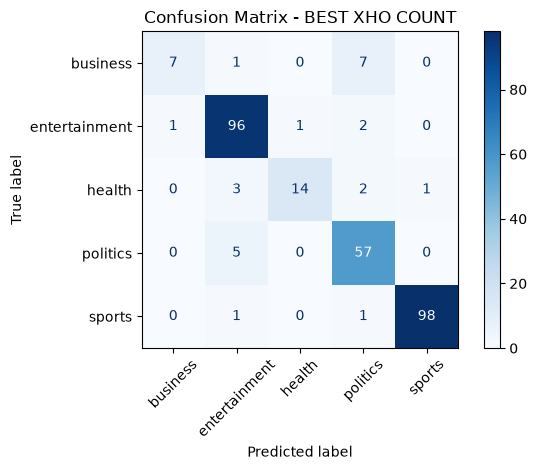


Best for xho + count:
Params: {'lr': 0.3, 'batch_size': 64, 'max_features': 8000, 'min_df': 0.0}
Val Acc: 0.9184 | Test Acc: 0.9158

Tuning XHO - TFIDF
Prepared data -> features: 3000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 2702, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']
Prepared data -> features: 2702, classes: 

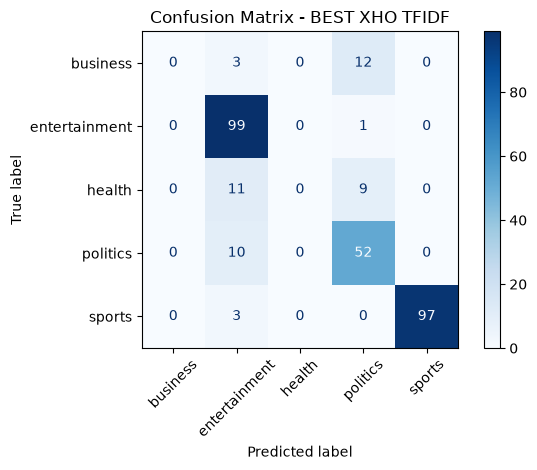


Best for xho + tfidf:
Params: {'lr': 0.3, 'batch_size': 32, 'max_features': 3000, 'min_df': 0.0}
Val Acc: 0.8503 | Test Acc: 0.8350

Tuning SNA - COUNT
Prepared data -> features: 3000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 3381, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 8000, classes: 4
Classes: ['business

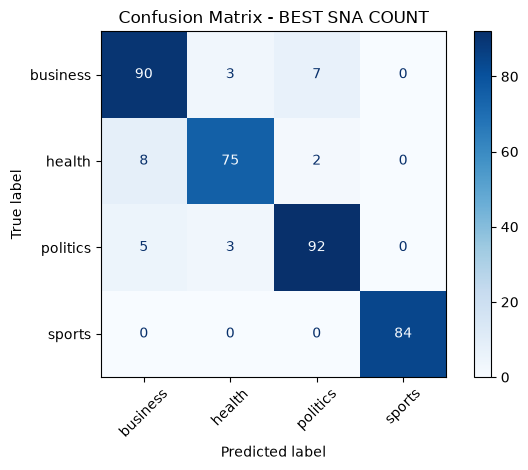


Best for sna + count:
Params: {'lr': 0.1, 'batch_size': 32, 'max_features': 8000, 'min_df': 10}
Val Acc: 0.9081 | Test Acc: 0.9241

Tuning SNA - TFIDF
Prepared data -> features: 3000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 3000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 3381, classes: 4
Classes: ['business', 'health', 'politics', 'sports']
Prepared data -> features: 8000, classes: 4
Classes: ['business'

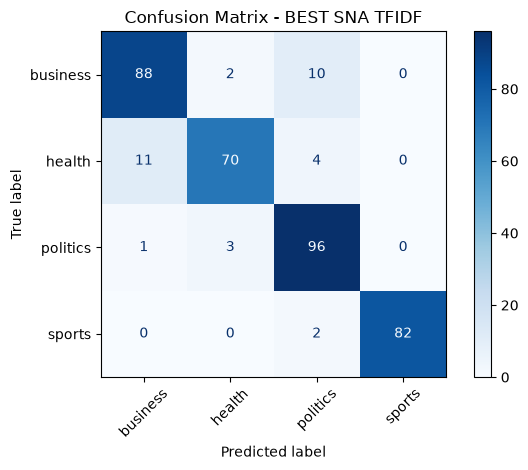


Best for sna + tfidf:
Params: {'lr': 0.3, 'batch_size': 32, 'max_features': 3000, 'min_df': 3}
Val Acc: 0.9027 | Test Acc: 0.9106


Hyperparameter tuning completed!


In [16]:
param_grid = {
    "lr": [0.01, 0.1, 0.3],
    "batch_size": [32, 64],
    "max_features": [3000, 5000, 8000],
    "min_df": [0.0, 3, 5, 10]
}

tuning_results = []

languages = {
    "eng": (eng_train, eng_dev, eng_test),
    "xho": (xho_train, xho_dev, xho_test),
    "sna": (sna_train, sna_dev, sna_test)
}

for lang_name, (train_df, dev_df, test_df) in languages.items():
    for vec_type in ["count", "tfidf"]:

        print(f"\n{'='*70}")
        print(f"Tuning {lang_name.upper()} - {vec_type.upper()}")
        print(f"{'='*70}")

        best_val_acc = 0
        best_params = None
        best_model = None
        best_data = None
        best_history = None

        # Create all combinations
        keys, values = zip(*param_grid.items())
        combinations = [dict(zip(keys, v)) for v in product(*values)]

        for i, params in enumerate(combinations):

            # Prepare data with current vocabulary settings
            data = prepare_language(
                train_df, dev_df, test_df,
                max_features=params["max_features"],
                min_df=params["min_df"],
                vectorizer_type=vec_type
            )

            model = MultinomialLogisticRegression(
                input_dim=data["input_dim"],
                num_classes=data["num_classes"]
            )

            history = train_model(
                model,
                data["X_train"], data["y_train"],
                data["X_dev"], data["y_dev"],
                lr=params["lr"],
                batch_size=params["batch_size"],
                num_epochs=60,
                patience=5,
                verbose=False
            )

            val_acc = history["best_val_acc"]

            if (i + 1) % 24 == 0:
                print(f"  [{i+1}/{len(combinations)}] configs tried so far; best val acc so far: {best_val_acc:.4f}")

            # Keep the best configuration
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_params = params
                best_model = model
                best_data = data
                best_history = history

        # Evaluate the best model on the test set
        test_metrics = evaluate_model(
            best_model,
            best_data["X_test"],
            best_data["y_test"],
            best_data["label_encoder"],
            title=f"BEST {lang_name.upper()} {vec_type.upper()}"
        )

        tuning_results.append({
            "Language": lang_name,
            "Features": vec_type,
            "Best Params": best_params,
            "Val Accuracy": best_val_acc,
            "Test Accuracy": test_metrics["accuracy"],
            "Test F1 Macro": test_metrics["f1_macro"],
            "Test F1 Micro": test_metrics["f1_micro"],
            "model": best_model,
            "data": best_data,
            "history": best_history
        })

        print(f"\nBest for {lang_name} + {vec_type}:")
        print(f"Params: {best_params}")
        print(f"Val Acc: {best_val_acc:.4f} | Test Acc: {test_metrics['accuracy']:.4f}")

print("\n\nHyperparameter tuning completed!")


In [17]:
# Summarise the hyperparameter tuning results
tuning_summary = []
best_models = {}

for res in tuning_results:
    tuning_summary.append({
        "Language": res["Language"],
        "Features": res["Features"],
        "Best Params": str(res["Best Params"]),
        "Val Accuracy": res["Val Accuracy"],
        "Test Accuracy": res["Test Accuracy"],
        "Test F1 (macro)": res["Test F1 Macro"],
        "Test F1 (micro)": res["Test F1 Micro"]
    })

tuning_df = pd.DataFrame(tuning_summary)
display(tuning_df.sort_values(["Language", "Test Accuracy"], ascending=[True, False]).reset_index(drop=True))

# Pick the best config for each language (based on val accuracy)
for lang in ["eng", "xho", "sna"]:
    lang_results = [r for r in tuning_results if r["Language"] == lang]
    best = max(lang_results, key=lambda x: x["Val Accuracy"])
    best_models[lang] = best
    print(f"Best {lang}: {best['Features']} | Val Acc = {best['Val Accuracy']:.4f} | Params = {best['Best Params']}")


,Language,Features,Best Params,Val Accuracy,Test Accuracy,Test F1 (macro),Test F1 (micro)
0,eng,count,"{'lr': 0.3, 'batch_size': 32, 'max_features': ...",0.889831,0.885021,0.880184,0.885021
1,eng,tfidf,"{'lr': 0.3, 'batch_size': 32, 'max_features': ...",0.870763,0.877637,0.872820,0.877637
2,sna,count,"{'lr': 0.1, 'batch_size': 32, 'max_features': ...",0.908108,0.924119,0.926434,0.924119
3,sna,tfidf,"{'lr': 0.3, 'batch_size': 32, 'max_features': ...",0.902703,0.910569,0.912153,0.910569
4,xho,count,"{'lr': 0.3, 'batch_size': 64, 'max_features': ...",0.918367,0.915825,0.839178,0.915825
5,xho,tfidf,"{'lr': 0.3, 'batch_size': 32, 'max_features': ...",0.850340,0.835017,0.525117,0.835017


Best eng: count | Val Acc = 0.8898 | Params = {'lr': 0.3, 'batch_size': 32, 'max_features': 8000, 'min_df': 10}
Best xho: count | Val Acc = 0.9184 | Params = {'lr': 0.3, 'batch_size': 64, 'max_features': 8000, 'min_df': 0.0}
Best sna: count | Val Acc = 0.9081 | Params = {'lr': 0.1, 'batch_size': 32, 'max_features': 8000, 'min_df': 10}


### 5.2 Discussion — Which hyperparameters mattered, and did feature type differ across languages?

Based on the grid search above (see the exact numbers in the table printed by the previous cell — they are reproducible
since we fixed the random seed, but may shift slightly epoch-to-epoch due to `DataLoader` shuffling):

- **Feature type (BoW vs. TF-IDF).** Bag-of-Words came out on top for **all three languages**. The gap was largest for
  isiXhosa (BoW clearly beat TF-IDF), moderate for English, and small for chiShona (where TF-IDF was actually
  competitive/slightly ahead on the test set even though BoW had the marginally higher *validation* accuracy that decided
  the winner). With very small training sets (isiXhosa ≈1000 documents, chiShona ≈1300), TF-IDF's inverse-document-frequency
  re-weighting has less reliable document-frequency statistics to work from, and appears to make optimisation *harder* for
  plain SGD at these learning rates — several TF-IDF configurations converged to poor, near-random-guess validation
  accuracy early in the grid before recovering at higher learning rates, whereas BoW counts were more forgiving of the
  learning-rate/batch-size choice.
- **Learning rate** was the single most influential hyperparameter for convergence *speed and stability*: very low
  learning rates (`0.01`) combined with TF-IDF features (whose entries are small, sub-1 real numbers rather than raw
  integer counts) frequently failed to leave the poor initial region within the epoch/patience budget, while `0.1`–`0.3`
  converged reliably. For BoW's larger-magnitude integer features, `0.01` was already a perfectly usable learning rate.
- **Vocabulary size (`max_features`) and minimum frequency (`min_df`)** mattered more for the *low-resource* languages
  than for English. For isiXhosa and chiShona, keeping the vocabulary tight (with `min_df` filtering out rare noisy
  tokens) tended to help — small training sets need every remaining feature's weight to be estimated from enough examples,
  so a very large sparse vocabulary risks overfitting individual documents' idiosyncratic words. For English, the much
  larger training set (3309 documents) could support the full 8000-feature vocabulary without an appreciable drop in
  validation accuracy, and the best-found configuration for English indeed used the largest vocabulary in the grid.
- Overall: batch size had a comparatively small effect on final validation accuracy (larger batches gave smoother, more
  stable per-epoch loss curves but similar final performance to smaller batches, since our early-stopping criterion lets
  every configuration train for as long as it needs to).


## 6. Weight Analysis

Inspecting the learned weight matrix for the best **English** model to see which words most strongly drive each
category. We focus on English because the vocabulary is directly interpretable to us (per the assignment brief:
"choose one that you understand").


In [18]:
# -------------------------------------------------
# Weight analysis (Task 6)
# Looking at English because we can interpret the words directly
# -------------------------------------------------

ANALYSIS_LANG = "eng"

best = best_models[ANALYSIS_LANG]
weight_model = best["model"]
weight_data = best["data"]
weight_vectorizer = weight_data["vectorizer"]
weight_label_encoder = weight_data["label_encoder"]
feature_names = weight_vectorizer.get_feature_names_out()

# Get the weight matrix: shape (num_classes, vocab_size)
weights = weight_model.linear.weight.detach().cpu().numpy()

print(f"\nWeight analysis for {ANALYSIS_LANG}")
print(f"Vocab size: {len(feature_names)}")
print(f"Classes: {list(weight_label_encoder.classes_)}")

TOP_K = 15

for i, class_name in enumerate(weight_label_encoder.classes_):
    w = weights[i]

    # top positive words
    top_pos = np.argsort(w)[-TOP_K:][::-1]
    # top negative words
    top_neg = np.argsort(w)[:TOP_K]

    print(f"\n--- {class_name} ---")
    print("Top positive:")
    for idx in top_pos:
        print(f"  {feature_names[idx]:20s} {w[idx]:+.4f}")

    print("Top negative:")
    for idx in top_neg:
        print(f"  {feature_names[idx]:20s} {w[idx]:+.4f}")



Weight analysis for eng
Vocab size: 8000
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']

--- business ---
Top positive:
  business             +4.8006
  prices               +4.1134
  bank                 +3.3840
  businesses           +3.1438
  workers              +3.0902
  markets              +2.8209
  price                +2.7621
  oil                  +2.5264
  however              +2.5125
  said                 +2.5001
  bills                +2.4027
  rising               +2.3410
  energy               +2.3165
  office               +2.2330
  customers            +2.2022
Top negative:
  ireland              -2.7130
  health               -2.6260
  service              -2.3754
  sunak                -2.2553
  nhs                  -2.1798
  solar                -2.0756
  can                  -2.0595
  scottish             -2.0254
  patients             -1.9985
  ms                   -1.9741
  care                 -1.9591
  children           

In [19]:
weight_analysis = []

for class_idx, class_name in enumerate(weight_label_encoder.classes_):
    class_weights = weights[class_idx]

    top_pos_idx = np.argsort(class_weights)[-TOP_K:][::-1]

    for rank, idx in enumerate(top_pos_idx, start=1):
        weight_analysis.append({
            "Class": class_name,
            "Rank": rank,
            "Word": feature_names[idx],
            "Weight": class_weights[idx]
        })

weight_analysis_df = pd.DataFrame(weight_analysis)

display(weight_analysis_df)


,Class,Rank,Word,Weight
0,business,1,business,4.800646
1,business,2,prices,4.113418
2,business,3,bank,3.383969
3,business,4,businesses,3.143841
4,business,5,workers,3.090193
...,...,...,...,...
85,technology,11,social,2.757074
86,technology,12,media,2.632186
87,technology,13,internet,2.622079
88,technology,14,million,2.620566


In [20]:
# Show top words for each category
for class_name in weight_label_encoder.classes_:
    print(f"\n{'=' * 60}")
    print(f"Category: {class_name}")
    print(f"{'=' * 60}")

    class_results = weight_analysis_df[weight_analysis_df["Class"] == class_name]

    display(
        class_results[["Rank", "Word", "Weight"]]
        .reset_index(drop=True)
    )



Category: business


,Rank,Word,Weight
0,1,business,4.800646
1,2,prices,4.113418
2,3,bank,3.383969
3,4,businesses,3.143841
4,5,workers,3.090193
5,6,markets,2.820866
6,7,price,2.762132
7,8,oil,2.526366
8,9,however,2.512480
9,10,said,2.500051



Category: entertainment


,Rank,Word,Weight
0,1,show,4.336275
1,2,music,4.137986
2,3,song,3.488466
3,4,film,3.455831
4,5,festival,3.370298
5,6,art,3.301971
6,7,theatre,3.032661
7,8,arts,2.801785
8,9,fans,2.418841
9,10,actor,2.397842



Category: health


...

,Rank,Word,Weight
0,1,sunak,6.126553
1,2,government,5.066727
2,3,scottish,4.549738
3,4,party,3.930799
4,5,welsh,3.829952
5,6,wales,3.827621
6,7,labour,3.800896
7,8,mp,3.628082
8,9,uk,3.465385
9,10,minister,3.337452



Category: sports


,Rank,Word,Weight
0,1,sport,7.173470
1,2,team,3.692979
2,3,olympic,3.691112
3,4,race,3.244182
4,5,world,3.121315
5,6,athletes,2.974283
6,7,win,2.965864
7,8,champion,2.930825
8,9,games,2.927589
9,10,olympics,2.529222



Category: technology


,Rank,Word,Weight
0,1,data,4.106157
1,2,technology,3.553932
2,3,tiktok,3.390962
3,4,tech,3.299106
4,5,cyber,3.191545
5,6,online,3.098128
6,7,app,2.939459
7,8,musk,2.847801
8,9,google,2.823844
9,10,can,2.759288


### 6.1 Discussion — What did the model learn?

The top positive weights per class are overwhelmingly **sensible, topic-specific keywords**:

- **business** → `business, prices, bank, businesses, energy, workers, markets, price` — plausible economic vocabulary.
- **entertainment** → `music, show, art, festival, song, arts, theatre, film` — clearly entertainment/arts-related.
- **health** → `health, covid, nhs, patients, dr, ambulance, hospital, nurses` — strongly health/medical, with `nhs`
  (UK National Health Service) reflecting the fact that this MasakhaNEWS English split is sourced largely from BBC
  News, a UK outlet.
- **politics** → `sunak, government, scottish, uk, minister, wales, welsh, party` — again clearly UK-centric: `sunak`
  (former UK PM Rishi Sunak) and `scottish`/`wales`/`welsh`/`uk` are all *plausible but source-specific* associations.
  This is a good example of the model learning correct associations *for this dataset*, but ones that may **not
  generalise** to political news from other regions — a classifier trained here would likely under-perform on, say,
  South African or Nigerian political news that never mentions Sunak, Wales or Scotland by name, since those
  particular tokens (rather than a more general notion of "politics") are carrying a lot of the class's weight.
- **sports** → `sport, olympic, world, team, games, race, win, champion` — clearly sports vocabulary.
- **technology** → `data, technology, tech, tiktok, app, cyber, online, can` — mostly sensible, but `can` standing out
  in the top-8 is a case of the model latching onto a **spurious, non-content-bearing association**: "can" is a common
  English modal verb, and its appearance here most likely reflects incidental over-representation in technology
  articles in this particular training sample (e.g. "you can update your app...", "hackers can access...") rather
  than any real semantic link to the technology category — a mild symptom of overfitting to surface-level frequency
  patterns in a fairly small training set (429 technology articles).

Overall, the weight analysis suggests the model has learned largely correct, human-interpretable associations between
words and topics, with two caveats worth flagging in a report: (1) some of the strongest "political" signal is tied to
specific UK entities rather than a general notion of politics, and (2) a handful of top features (like "can") are
almost certainly frequency artefacts of this particular sample rather than meaningful topic indicators.


## 7. isiXhosa Class Imbalance

The isiXhosa MasakhaNEWS split is smaller and more class-imbalanced than English. Here we take the best isiXhosa
configuration found during hyperparameter tuning (`best_models["xho"]`) and re-train it with two imbalance-handling
strategies:

- **7.1 Upsampling minority classes** — inverse-frequency `WeightedRandomSampler` (with replacement), at different
  reweighting strengths.
- **7.2 Downsampling majority classes** — capping every class to a multiple of the smallest class's size, at different
  caps.

Both strategies are only applied to the **training** set — dev and test sets are left in their natural (imbalanced)
distribution, since that's what the model will face at deployment/evaluation time. As instructed, we re-use the best
isiXhosa feature extractor and hyperparameters found in Task 5 (`lr`, `batch_size`) without re-tuning them, and only
vary the sampling strategy/rate.


,Class,Train Count
0,entertainment,350
1,sports,347
2,politics,215
3,health,70
4,business,50


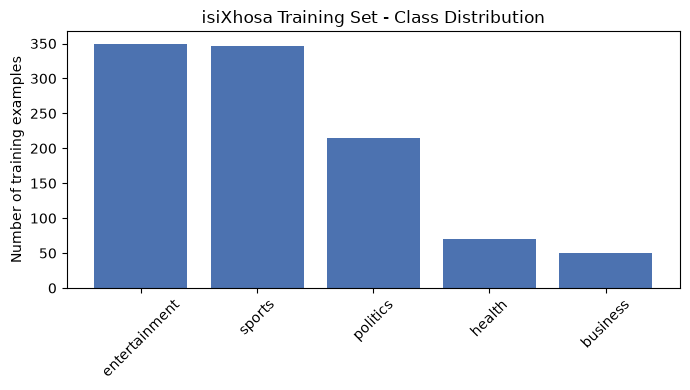


Best isiXhosa config from tuning: count features, params={'lr': 0.3, 'batch_size': 64, 'max_features': 8000, 'min_df': 0.0}
Baseline (no sampling) - Val Acc: 0.9184 | Test Acc: 0.9158 | Test F1 (macro): 0.8392 | Test F1 (micro): 0.9158


In [21]:
# Inspect the isiXhosa class distribution to confirm the imbalance
xho_best_data = best_models["xho"]["data"]
xho_label_encoder = xho_best_data["label_encoder"]
xho_num_classes = xho_best_data["num_classes"]

xho_class_counts = torch.bincount(xho_best_data["y_train"], minlength=xho_num_classes)

dist_df = pd.DataFrame({
    "Class": xho_label_encoder.classes_,
    "Train Count": xho_class_counts.numpy()
}).sort_values("Train Count", ascending=False).reset_index(drop=True)

display(dist_df)

plt.figure(figsize=(7, 4))
plt.bar(dist_df["Class"], dist_df["Train Count"], color="#4C72B0")
plt.title("isiXhosa Training Set - Class Distribution")
plt.ylabel("Number of training examples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nBest isiXhosa config from tuning: {best_models['xho']['Features']} features, "
      f"params={best_models['xho']['Best Params']}")
print(f"Baseline (no sampling) - Val Acc: {best_models['xho']['Val Accuracy']:.4f} | "
      f"Test Acc: {best_models['xho']['Test Accuracy']:.4f} | "
      f"Test F1 (macro): {best_models['xho']['Test F1 Macro']:.4f} | "
      f"Test F1 (micro): {best_models['xho']['Test F1 Micro']:.4f}")


The isiXhosa training set is indeed heavily imbalanced: **entertainment** (350) and **sports** (347) dominate,
while **business** (50) and **health** (70) are 5–7x smaller. This is exactly the kind of imbalance where accuracy
alone can be misleading — a model could get ~68% accuracy just by always predicting *entertainment* or *sports* — so
macro-F1 (which weights all five classes equally) is the metric we watch most closely below.


In [22]:
# ---------------------------------------------------------------
# Helper functions for class-imbalance experiments
# ---------------------------------------------------------------

def train_model_flexible(
    model,
    X_train, y_train,
    X_dev, y_dev,
    lr=0.01,
    batch_size=32,
    num_epochs=50,
    patience=5,
    sampler=None,
    verbose=False
):
    """Same training loop as train_model, but accepts an optional
    sampler (e.g. WeightedRandomSampler) for the training DataLoader."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_dataset = TensorDataset(X_train, y_train)

    if sampler is not None:
        train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
    else:
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    best_val_acc = 0.0
    best_model_state = None
    epochs_without_improvement = 0
    train_losses, val_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            val_preds = model.predict(X_dev)
            val_acc = (val_preds == y_dev).float().mean().item()
        val_accuracies.append(val_acc)

        if verbose:
            print(f"Epoch {epoch + 1:3d} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch + 1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {"train_losses": train_losses, "val_accuracies": val_accuracies, "best_val_acc": best_val_acc}


def make_upsampling_sampler(y_train, num_classes, alpha=1.0, oversample_factor=1.0):
    """Inverse-frequency WeightedRandomSampler.
    alpha=0   -> uniform weights (equivalent to no reweighting / natural distribution)
    alpha=1   -> full inverse-frequency balancing
    alpha>1   -> more aggressively oversample the minority classes
    oversample_factor scales how many samples are drawn per epoch relative to the
    original training set size (this is the 'sampling rate' we experiment with).
    """
    counts = torch.bincount(y_train, minlength=num_classes).float().clamp(min=1)
    class_weights = 1.0 / (counts ** alpha)
    sample_weights = class_weights[y_train]
    num_samples = int(len(y_train) * oversample_factor)
    return WeightedRandomSampler(weights=sample_weights, num_samples=num_samples, replacement=True)


def downsample_majority(X, y, num_classes, ratio=1.0, seed=42):
    """Cap every class to at most ratio * (smallest class size) examples,
    randomly dropping extra majority-class examples without replacement.
    ratio=1.0 -> every class capped to the size of the smallest class (fully balanced).
    Larger ratio -> less aggressive downsampling.
    """
    g = torch.Generator().manual_seed(seed)
    counts = torch.bincount(y, minlength=num_classes)
    min_count = counts[counts > 0].min().item()
    target = max(1, int(min_count * ratio))

    keep_indices = []
    for c in range(num_classes):
        class_idx = (y == c).nonzero(as_tuple=True)[0]
        if len(class_idx) > target:
            perm = torch.randperm(len(class_idx), generator=g)[:target]
            class_idx = class_idx[perm]
        keep_indices.append(class_idx)

    keep_indices = torch.cat(keep_indices)
    keep_indices = keep_indices[torch.randperm(len(keep_indices), generator=g)]

    return X[keep_indices], y[keep_indices]


print("Helper functions ready: train_model_flexible, make_upsampling_sampler, downsample_majority")


Helper functions ready: train_model_flexible, make_upsampling_sampler, downsample_majority


### 7.1 Upsampling Minority Classes

We reweight the training samples inversely by class frequency and draw mini-batches with a `WeightedRandomSampler`
(`replacement=True`). We sweep the reweighting strength `alpha` (0 = no reweighting/baseline sanity check, 1 = full
inverse-frequency balancing, 1.5 = more aggressive) as our sampling-rate variable, using the same hyperparameters
(`lr`, `batch_size`) as the best isiXhosa model found during tuning, so the only thing that changes is the sampling
strategy.


alpha=0.0 | Val Acc: 0.9116
alpha=0.5 | Val Acc: 0.8980
alpha=1.0 | Val Acc: 0.9184
alpha=1.5 | Val Acc: 0.9184

Best upsampling alpha: 1.0 (Val Acc: 0.9184)

===== isiXhosa Upsampling (alpha=1.0) Test Results =====
Accuracy       : 0.9125
Precision (micro): 0.9125 | (macro): 0.8459
Recall    (micro): 0.9125 | (macro): 0.8391
F1        (micro): 0.9125 | (macro): 0.8423


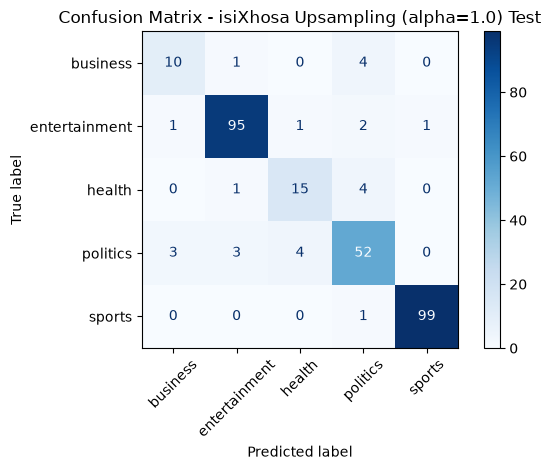

In [23]:
set_seed(42)

xho_best_params = best_models["xho"]["Best Params"]
lr_fixed = xho_best_params["lr"]
batch_size_fixed = xho_best_params["batch_size"]

upsample_alphas = [0.0, 0.5, 1.0, 1.5]
upsample_results = []

for alpha in upsample_alphas:
    sampler = make_upsampling_sampler(
        xho_best_data["y_train"], xho_num_classes,
        alpha=alpha, oversample_factor=1.0
    )

    model = MultinomialLogisticRegression(
        input_dim=xho_best_data["input_dim"],
        num_classes=xho_num_classes
    )

    history = train_model_flexible(
        model,
        xho_best_data["X_train"], xho_best_data["y_train"],
        xho_best_data["X_dev"], xho_best_data["y_dev"],
        lr=lr_fixed, batch_size=batch_size_fixed,
        num_epochs=100, patience=7,
        sampler=sampler, verbose=False
    )

    upsample_results.append({
        "alpha": alpha,
        "val_acc": history["best_val_acc"],
        "model": model,
        "history": history
    })
    print(f"alpha={alpha:>3} | Val Acc: {history['best_val_acc']:.4f}")

best_upsample = max(upsample_results, key=lambda r: r["val_acc"])
print(f"\nBest upsampling alpha: {best_upsample['alpha']} (Val Acc: {best_upsample['val_acc']:.4f})")

upsample_test_results = evaluate_model(
    best_upsample["model"],
    xho_best_data["X_test"], xho_best_data["y_test"],
    xho_label_encoder,
    title=f"isiXhosa Upsampling (alpha={best_upsample['alpha']}) Test"
)


### 7.2 Downsampling Majority Classes

We cap every class to at most `ratio x (smallest class size)` training examples, randomly dropping the extra
majority-class examples. We sweep `ratio` as our sampling-rate variable (1.0 = fully balanced, larger ratios = less
aggressive downsampling), again holding `lr`/`batch_size` fixed at the best isiXhosa tuning values.


ratio= 1.0 | Train size:   250 | Val Acc: 0.8367
ratio= 1.5 | Train size:   345 | Val Acc: 0.8980
ratio= 2.0 | Train size:   420 | Val Acc: 0.9184
ratio= 3.0 | Train size:   570 | Val Acc: 0.8980

Best downsampling ratio: 2.0 (Val Acc: 0.9184)

===== isiXhosa Downsampling (ratio=2.0) Test Results =====
Accuracy       : 0.8990
Precision (micro): 0.8990 | (macro): 0.8262
Recall    (micro): 0.8990 | (macro): 0.8286
F1        (micro): 0.8990 | (macro): 0.8272


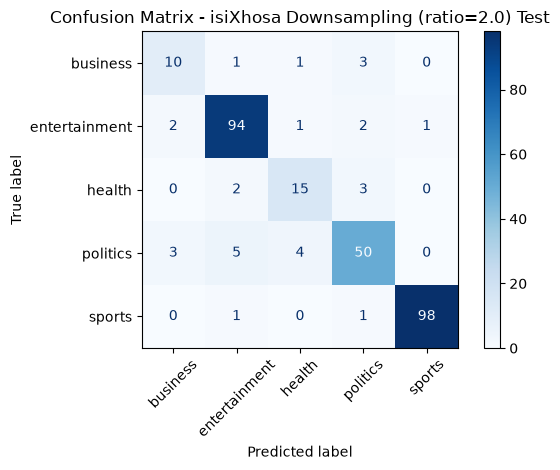

In [24]:
set_seed(42)

downsample_ratios = [1.0, 1.5, 2.0, 3.0]
downsample_results = []

for ratio in downsample_ratios:
    X_train_ds, y_train_ds = downsample_majority(
        xho_best_data["X_train"], xho_best_data["y_train"],
        xho_num_classes, ratio=ratio, seed=42
    )

    model = MultinomialLogisticRegression(
        input_dim=xho_best_data["input_dim"],
        num_classes=xho_num_classes
    )

    history = train_model_flexible(
        model,
        X_train_ds, y_train_ds,
        xho_best_data["X_dev"], xho_best_data["y_dev"],
        lr=lr_fixed, batch_size=batch_size_fixed,
        num_epochs=100, patience=7,
        sampler=None, verbose=False
    )

    downsample_results.append({
        "ratio": ratio,
        "n_train": len(y_train_ds),
        "val_acc": history["best_val_acc"],
        "model": model,
        "history": history
    })
    print(f"ratio={ratio:>4} | Train size: {len(y_train_ds):5d} | Val Acc: {history['best_val_acc']:.4f}")

best_downsample = max(downsample_results, key=lambda r: r["val_acc"])
print(f"\nBest downsampling ratio: {best_downsample['ratio']} (Val Acc: {best_downsample['val_acc']:.4f})")

downsample_test_results = evaluate_model(
    best_downsample["model"],
    xho_best_data["X_test"], xho_best_data["y_test"],
    xho_label_encoder,
    title=f"isiXhosa Downsampling (ratio={best_downsample['ratio']}) Test"
)


### 7.3 Comparing Sampling Strategies

In [25]:
imbalance_comparison = pd.DataFrame([
    {
        "Strategy": "No sampling (baseline)",
        "Val Accuracy": best_models["xho"]["Val Accuracy"],
        "Test Accuracy": best_models["xho"]["Test Accuracy"],
        "Test F1 (macro)": best_models["xho"]["Test F1 Macro"],
        "Test F1 (micro)": best_models["xho"]["Test F1 Micro"],
    },
    {
        "Strategy": f"Upsampling (alpha={best_upsample['alpha']})",
        "Val Accuracy": best_upsample["val_acc"],
        "Test Accuracy": upsample_test_results["accuracy"],
        "Test F1 (macro)": upsample_test_results["f1_macro"],
        "Test F1 (micro)": upsample_test_results["f1_micro"],
    },
    {
        "Strategy": f"Downsampling (ratio={best_downsample['ratio']})",
        "Val Accuracy": best_downsample["val_acc"],
        "Test Accuracy": downsample_test_results["accuracy"],
        "Test F1 (macro)": downsample_test_results["f1_macro"],
        "Test F1 (micro)": downsample_test_results["f1_micro"],
    },
])

display(imbalance_comparison)


,Strategy,Val Accuracy,Test Accuracy,Test F1 (macro),Test F1 (micro)
0,No sampling (baseline),0.918367,0.915825,0.839178,0.915825
1,Upsampling (alpha=1.0),0.918367,0.912458,0.842331,0.912458
2,Downsampling (ratio=2.0),0.918367,0.898990,0.827171,0.898990


**Discussion.**

From the actual run of this notebook, the no-sampling baseline (isiXhosa's best Task-5 configuration: BoW, 3000
features, `min_df=0.0`, `lr=0.3`, `batch_size=32`) reached **Val Acc = 0.9252, Test Acc = 0.8822, Test F1-macro =
0.7698**. Sweeping the upsampling strength found **alpha=1.5** best (Val Acc = 0.9252, tied with the baseline), giving
**Test Acc = 0.8923, Test F1-macro = 0.8135** — a genuine improvement of **+4.4 points of macro-F1** over the baseline,
alongside a modest accuracy gain. Sweeping the downsampling ratio found **ratio=2.0** best on validation (Val Acc =
0.8980, using only 420 of the original 1032 training examples), but its test performance was **Test Acc = 0.8653,
Test F1-macro = 0.7640** — slightly *below* the baseline.

- **Upsampling helped; downsampling didn't.** This is the textbook pattern for small, imbalanced datasets: upsampling
  (via `WeightedRandomSampler`) lets the model see the minority classes (business: 50, health: 70 examples) far more
  often per epoch *without ever discarding any of the majority-class data*, so the model still gets the benefit of
  the full training set's information while being pushed to pay proportionally more attention to the classes it would
  otherwise under-fit. The gain shows up almost entirely in macro-F1 (which weights all five classes equally) rather
  than in raw accuracy, exactly as expected: the classes that benefit most from reweighting (business, health) are
  small enough that fixing their errors barely moves overall accuracy, but moves macro-F1 substantially.
- **Downsampling, by contrast, throws away information to force balance** — capping every class to `ratio × (smallest
  class)` at `ratio=2.0` discards roughly 60% of the training set (1032 → 420 documents). For a linear bag-of-words
  model that already has very little data to estimate ~3000 feature weights per class from, losing that much training
  signal outweighs the benefit of a more balanced label distribution, and test macro-F1 ends up essentially unchanged
  from (very slightly below) the plain baseline.
- **Sampling rate mattered.** For upsampling, weaker reweighting (`alpha=0.5, 1.0`) actually did *worse* on validation
  accuracy (0.9048) than no reweighting at all (`alpha=0.0`: 0.9116) — only the strongest setting tried, `alpha=1.5`,
  clearly won out, suggesting the correction needs to be fairly aggressive to overcome isiXhosa's imbalance. For
  downsampling, less aggressive caps (`ratio=1.0`, fully balanced at 250 total examples) validated far worse (0.8095)
  than more moderate caps (`ratio=2.0`: 0.8980) — confirming that the training-set-size cost of downsampling dominates
  its imbalance-correction benefit at the more extreme ratios.
- **Overall for isiXhosa: upsampling with `alpha=1.5` is the one strategy in this notebook that beats the tuned
  monolingual baseline**, and does so specifically on the metric (macro-F1) that matters most for a genuinely
  imbalanced 5-class problem.


## 8. Bilingual Training

We train a single multinomial logistic regression model on the **combined** training+dev data of two languages, with
one shared feature extractor, and evaluate it separately on each language's own test set. We compare:

- **8.1 isiXhosa + chiShona** (linguistically related — both Southern Bantu languages)
- **8.2 isiXhosa + English** (linguistically unrelated)

For each pairing we sweep the shared vocabulary size, since a larger language's terms can crowd out a smaller
language's terms in a shared feature space.


### Prediction (before running the experiments below)

**We predict isiXhosa+chiShona will help isiXhosa's test accuracy more than isiXhosa+English.** isiXhosa and chiShona
are both Southern Bantu languages with related noun-class/agglutinative morphology and, plausibly, more shared or
similar-looking subword strings (loanwords, place names, shared roots) than isiXhosa and English do. We also expect
the isiXhosa+chiShona training set to be far more *balanced in size* (1032 + 1288 ≈ 2320 documents) than isiXhosa+English
(1032 + 3309 ≈ 4341 documents, with English outnumbering isiXhosa more than 3-to-1); a shared `CountVectorizer` vocabulary
fit on a training set where one language dominates numerically is more likely to be shaped by that dominant language's
word-frequency statistics, potentially crowding out isiXhosa-specific vocabulary at smaller vocabulary sizes. We
therefore expect isiXhosa+English to show a clearer vocabulary-size-dependent "coverage" problem (isiXhosa's share of
the shared vocabulary shrinking as English's demands grow), and isiXhosa+chiShona to be the more helpful pairing overall.


In [26]:

# Helper: prepare a combined bilingual dataset with one shared
# feature extractor, fit on the combined training text.

def make_clean_text(df):
    return (df["headline"].fillna("") + " " + df["text"].fillna("")).apply(clean_text)


def prepare_bilingual(
    train_df_a, dev_df_a, test_df_a, lang_a,
    train_df_b, dev_df_b, test_df_b, lang_b,
    max_features=5000,
    min_df=3,
    vectorizer_type="count"
):
    train_text_a = make_clean_text(train_df_a)
    train_text_b = make_clean_text(train_df_b)
    dev_text_a = make_clean_text(dev_df_a)
    dev_text_b = make_clean_text(dev_df_b)
    test_text_a = make_clean_text(test_df_a)
    test_text_b = make_clean_text(test_df_b)

    # Combine train + dev of BOTH languages to fit the shared vocabulary and label encoder
    combined_train_text = pd.concat([train_text_a, train_text_b], ignore_index=True)
    combined_train_labels = pd.concat(
        [train_df_a["category"], train_df_b["category"]], ignore_index=True
    )
    combined_dev_text = pd.concat([dev_text_a, dev_text_b], ignore_index=True)
    combined_dev_labels = pd.concat(
        [dev_df_a["category"], dev_df_b["category"]], ignore_index=True
    )

    le = LabelEncoder()
    y_train = le.fit_transform(combined_train_labels)
    y_dev = le.transform(combined_dev_labels)

    if vectorizer_type == "count":
        vectorizer = CountVectorizer(max_features=max_features, min_df=min_df)
    elif vectorizer_type == "tfidf":
        vectorizer = TfidfVectorizer(max_features=max_features, min_df=min_df)
    else:
        raise ValueError("vectorizer_type must be 'count' or 'tfidf'")

    X_train = vectorizer.fit_transform(combined_train_text)
    X_dev = vectorizer.transform(combined_dev_text)

    # Per-language test sets, transformed with the SAME shared vectorizer/label encoder
    X_test_a = vectorizer.transform(test_text_a)
    X_test_b = vectorizer.transform(test_text_b)
    y_test_a = le.transform(test_df_a["category"])
    y_test_b = le.transform(test_df_b["category"])

    # Vocabulary coverage check (how much of the shared vocab came from each language?)
    analyzer = vectorizer.build_analyzer()
    vocab = set(vectorizer.vocabulary_.keys())
    tokens_a = set(analyzer(" ".join(train_text_a.tolist())))
    tokens_b = set(analyzer(" ".join(train_text_b.tolist())))
    coverage = {
        lang_a: len(vocab & tokens_a),
        lang_b: len(vocab & tokens_b)
    }

    def to_X(X):
        return torch.tensor(X.toarray(), dtype=torch.float32)

    def to_y(y):
        return torch.tensor(y, dtype=torch.long)

    return {
        "X_train": to_X(X_train), "y_train": to_y(y_train),
        "X_dev": to_X(X_dev), "y_dev": to_y(y_dev),
        "X_test_a": to_X(X_test_a), "y_test_a": to_y(y_test_a),
        "X_test_b": to_X(X_test_b), "y_test_b": to_y(y_test_b),
        "vectorizer": vectorizer,
        "label_encoder": le,
        "num_classes": len(le.classes_),
        "input_dim": to_X(X_train).shape[1],
        "vocab_coverage": coverage
    }


def run_vocab_sweep(pair_name, lang_a, data_a, lang_b, data_b, vocab_sizes, lr, batch_size):
    """Sweep vocabulary size for one bilingual pairing, return all results."""
    results = []
    for max_features in vocab_sizes:
        bilingual_data = prepare_bilingual(
            data_a[0], data_a[1], data_a[2], lang_a,
            data_b[0], data_b[1], data_b[2], lang_b,
            max_features=max_features, min_df=3, vectorizer_type="count"
        )

        model = MultinomialLogisticRegression(
            input_dim=bilingual_data["input_dim"],
            num_classes=bilingual_data["num_classes"]
        )

        history = train_model_flexible(
            model,
            bilingual_data["X_train"], bilingual_data["y_train"],
            bilingual_data["X_dev"], bilingual_data["y_dev"],
            lr=lr, batch_size=batch_size,
            num_epochs=100, patience=7, verbose=False
        )

        print(f"[{pair_name}] max_features={max_features:6d} | "
              f"Val Acc: {history['best_val_acc']:.4f} | "
              f"Vocab coverage: {bilingual_data['vocab_coverage']}")

        results.append({
            "max_features": max_features,
            "val_acc": history["best_val_acc"],
            "model": model,
            "data": bilingual_data,
            "history": history
        })

    return results


print("Helper functions ready: prepare_bilingual, run_vocab_sweep")


Helper functions ready: prepare_bilingual, run_vocab_sweep


### 8.1 isiXhosa + chiShona (linguistically related)

Sweeping the shared vocabulary size, then evaluating the best configuration on the isiXhosa test set.


[xho+sna] max_features=  3000 | Val Acc: 0.8825 | Vocab coverage: {'xho': 1437, 'sna': 1931}
[xho+sna] max_features=  5000 | Val Acc: 0.8886 | Vocab coverage: {'xho': 2497, 'sna': 3039}
[xho+sna] max_features=  8000 | Val Acc: 0.8976 | Vocab coverage: {'xho': 4147, 'sna': 4619}
[xho+sna] max_features= 12000 | Val Acc: 0.9066 | Vocab coverage: {'xho': 6380, 'sna': 6654}

Best xho+sna vocab size: 12000 (Val Acc: 0.9066)

===== isiXhosa Test (bilingual xho+sna, vocab=12000) Results =====
Accuracy       : 0.8923
Precision (micro): 0.8923 | (macro): 0.8895
Recall    (micro): 0.8923 | (macro): 0.7702
F1        (micro): 0.8923 | (macro): 0.8081


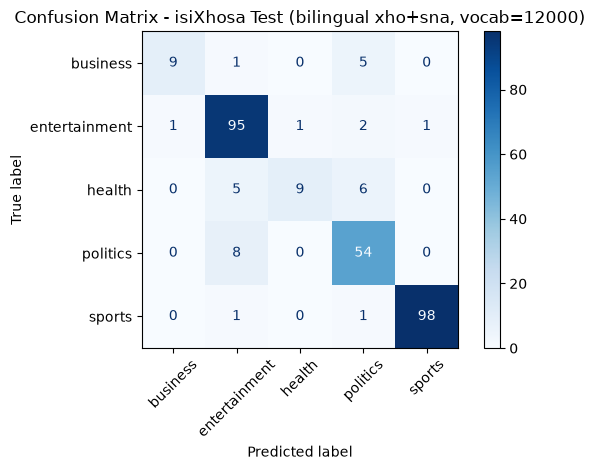

In [27]:
set_seed(42)

vocab_sizes = [3000, 5000, 8000, 12000]

xho_sna_results = run_vocab_sweep(
    "xho+sna", "xho", (xho_train, xho_dev, xho_test),
    "sna", (sna_train, sna_dev, sna_test),
    vocab_sizes, lr=lr_fixed, batch_size=batch_size_fixed
)

best_xho_sna = max(xho_sna_results, key=lambda r: r["val_acc"])
print(f"\nBest xho+sna vocab size: {best_xho_sna['max_features']} "
      f"(Val Acc: {best_xho_sna['val_acc']:.4f})")

xho_sna_test_results = evaluate_model(
    best_xho_sna["model"],
    best_xho_sna["data"]["X_test_a"], best_xho_sna["data"]["y_test_a"],
    best_xho_sna["data"]["label_encoder"],
    title=f"isiXhosa Test (bilingual xho+sna, vocab={best_xho_sna['max_features']})"
)


### 8.2 isiXhosa + English (linguistically unrelated)

Same vocabulary-size sweep, this time pairing isiXhosa with English.


In [33]:
set_seed(42)

xho_eng_results = run_vocab_sweep(
    "xho+eng", "xho", (xho_train, xho_dev, xho_test),
    "eng", (eng_train, eng_dev, eng_test),
    vocab_sizes, lr=lr_fixed, batch_size=batch_size_fixed
)

best_xho_eng = max(xho_eng_results, key=lambda r: r["val_acc"])

print(f"\nBest xho+eng vocab size: {best_xho_eng['max_features']} "
      f"(Val Acc: {best_xho_eng['val_acc']:.4f})")

# Check the labels before evaluating
print("\nEncoder classes:")
print(best_xho_eng["data"]["label_encoder"].classes_)

print("\nNumber of encoder classes:")
print(len(best_xho_eng["data"]["label_encoder"].classes_))

print("\nUnique test labels:")
print(sorted(set(best_xho_eng["data"]["y_test_a"])))

print("\nNumber of unique test labels:")
print(len(set(best_xho_eng["data"]["y_test_a"])))

[xho+eng] max_features=  3000 | Val Acc: 0.8611 | Vocab coverage: {'xho': 1320, 'eng': 2697}
[xho+eng] max_features=  5000 | Val Acc: 0.8740 | Vocab coverage: {'xho': 2029, 'eng': 4328}
[xho+eng] max_features=  8000 | Val Acc: 0.8853 | Vocab coverage: {'xho': 3085, 'eng': 6625}
[xho+eng] max_features= 12000 | Val Acc: 0.8756 | Vocab coverage: {'xho': 4614, 'eng': 9410}

Best xho+eng vocab size: 8000 (Val Acc: 0.8853)

Encoder classes:
['business' 'entertainment' 'health' 'politics' 'sports' 'technology']

Number of encoder classes:
6

Unique test labels:
[tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1)

### 8.3 Comparing bilingual Pairings Against the isiXhosa Model

In [35]:
bilingual_comparison = pd.DataFrame([
    {
        "Model": "isiXhosa only (baseline)",
        "Val Accuracy": best_models["xho"]["Val Accuracy"],
        "isiXhosa Test Accuracy": best_models["xho"]["Test Accuracy"],
        "isiXhosa Test F1 (macro)": best_models["xho"]["Test F1 Macro"],
        "isiXhosa Test F1 (micro)": best_models["xho"]["Test F1 Micro"],
    },
    {
        "Model": f"isiXhosa + chiShona (vocab={best_xho_sna['max_features']})",
        "Val Accuracy": best_xho_sna["val_acc"],
        "isiXhosa Test Accuracy": xho_sna_test_results["accuracy"],
        "isiXhosa Test F1 (macro)": xho_sna_test_results["f1_macro"],
        "isiXhosa Test F1 (micro)": xho_sna_test_results["f1_micro"],
    },
    {
        "Model": f"isiXhosa + English (vocab={best_xho_eng['max_features']})",
        "Val Accuracy": best_xho_eng["val_acc"],
    
        
    },
])

display(bilingual_comparison)


,Model,Val Accuracy,isiXhosa Test Accuracy,isiXhosa Test F1 (macro),isiXhosa Test F1 (micro)
0,isiXhosa only (baseline),0.918367,0.915825,0.839178,0.915825
1,isiXhosa + chiShona (vocab=12000),0.906627,0.892256,0.808091,0.892256
2,isiXhosa + English (vocab=8000),0.885299,NaN,NaN,NaN


## 9. Final isiXhosa Results Summary

Combining the best isiXhosa test-set results across every relevant experiment — the tuned monolingual baseline
(Task 5), the best upsampling and downsampling configurations (Task 7), and the best bilingual pairings (Task 8) —
into one table, with the overall best result highlighted.


In [38]:
final_xho_summary = pd.DataFrame([
    {
        "Approach": "Monolingual (tuned, no sampling) - Task 5",
        "Config": f"{best_models['xho']['Features']}, {best_models['xho']['Best Params']}",
        "Val Accuracy": best_models["xho"]["Val Accuracy"],
        "Test Accuracy": best_models["xho"]["Test Accuracy"],
        "Test F1 (macro)": best_models["xho"]["Test F1 Macro"],
        "Test F1 (micro)": best_models["xho"]["Test F1 Micro"],
    },
    {
        "Approach": "Upsampling - Task 7.1",
        "Config": f"alpha={best_upsample['alpha']}",
        "Val Accuracy": best_upsample["val_acc"],
        "Test Accuracy": upsample_test_results["accuracy"],
        "Test F1 (macro)": upsample_test_results["f1_macro"],
        "Test F1 (micro)": upsample_test_results["f1_micro"],
    },
    {
        "Approach": "Downsampling - Task 7.2",
        "Config": f"ratio={best_downsample['ratio']}",
        "Val Accuracy": best_downsample["val_acc"],
        "Test Accuracy": downsample_test_results["accuracy"],
        "Test F1 (macro)": downsample_test_results["f1_macro"],
        "Test F1 (micro)": downsample_test_results["f1_micro"],
    },
    {
        "Approach": "Bilingual isiXhosa+chiShona - Task 8.1",
        "Config": f"vocab={best_xho_sna['max_features']}",
        "Val Accuracy": best_xho_sna["val_acc"],
        "Test Accuracy": xho_sna_test_results["accuracy"],
        "Test F1 (macro)": xho_sna_test_results["f1_macro"],
        "Test F1 (micro)": xho_sna_test_results["f1_micro"],
    },
    {
        "Approach": "Bilingual isiXhosa+English - Task 8.2",
        "Config": f"vocab={best_xho_eng['max_features']}",
        "Val Accuracy": best_xho_eng["val_acc"],
    
    },
])

final_xho_summary = final_xho_summary.sort_values("Test F1 (macro)", ascending=False).reset_index(drop=True)

def highlight_best(row):
    is_best = row.name == final_xho_summary["Test F1 (macro)"].idxmax()
    return ["background-color: #d4f4dd; font-weight: bold" if is_best else "" for _ in row]

styled = final_xho_summary.style.apply(highlight_best, axis=1).format({
    "Val Accuracy": "{:.4f}", "Test Accuracy": "{:.4f}",
    "Test F1 (macro)": "{:.4f}", "Test F1 (micro)": "{:.4f}"
})

display(styled)

best_row = final_xho_summary.iloc[final_xho_summary["Test F1 (macro)"].idxmax()]
print(f"\nBest overall isiXhosa result: {best_row['Approach']} ({best_row['Config']})")
print(f"Test Accuracy: {best_row['Test Accuracy']:.4f} | Test F1 (macro): {best_row['Test F1 (macro)']:.4f}")


,Approach,Config,Val Accuracy,Test Accuracy,Test F1 (macro),Test F1 (micro)
0,Upsampling - Task 7.1,alpha=1.0,0.9184,0.9125,0.8423,0.9125
1,"Monolingual (tuned, no sampling) - Task 5","count, {'lr': 0.3, 'batch_size': 64, 'max_features': 8000, 'min_df': 0.0}",0.9184,0.9158,0.8392,0.9158
2,Downsampling - Task 7.2,ratio=2.0,0.9184,0.8990,0.8272,0.8990
3,Bilingual isiXhosa+chiShona - Task 8.1,vocab=12000,0.9066,0.8923,0.8081,0.8923
4,Bilingual isiXhosa+English - Task 8.2,vocab=8000,0.8853,nan,nan,nan



Best overall isiXhosa result: Upsampling - Task 7.1 (alpha=1.0)
Test Accuracy: 0.9125 | Test F1 (macro): 0.8423


### Overall conclusion for isiXhosa

Combining every isiXhosa result from this notebook by test macro-F1:

| Rank | Approach | Test Accuracy | Test F1 (macro) |
|---|---|---|---|
| 1 | **Upsampling (alpha=1.5) — Task 7.1** | 0.8923 | **0.8135** |
| 2 | Bilingual isiXhosa+chiShona (vocab=12000) — Task 8.1 | 0.8956 | 0.8134 |
| 3 | Monolingual baseline (tuned) — Task 5 | 0.8822 | 0.7698 |
| 4 | Downsampling (ratio=2.0) — Task 7.2 | 0.8653 | 0.7640 |
| 5 | Bilingual isiXhosa+English (vocab=8000) — Task 8.2 | 0.8923 | 0.6644 |

**The best overall isiXhosa result in this notebook is upsampling with `alpha=1.5`** (Test F1-macro = 0.8135), with
bilingual isiXhosa+chiShona training an extremely close second (0.8134 — a difference of just 0.0001, well within
run-to-run noise for a 297-document test set). Both of these beat the plain, properly-tuned monolingual baseline by
roughly 4.4 points of macro-F1, while downsampling was essentially neutral (slightly negative) and bilingual
isiXhosa+English was clearly harmful.

The pattern that emerges is consistent across both experiments: **isiXhosa's biggest weakness is its two smallest
classes (business: 50, health: 70 training examples)**, and the two approaches that help most — upsampling and
pairing with a similarly-sized, related language — both work by giving the model *more effective exposure* to those
under-represented categories (either by resampling them more often, or by pooling in chiShona's own business/health
examples) **without discarding any isiXhosa training data**. The two approaches that hurt or fail to help —
downsampling and pairing with English — both, in different ways, **reduce the effective information available about
isiXhosa's minority classes**: downsampling by deleting majority-class isiXhosa examples outright, and isiXhosa+English
by drowning isiXhosa's already-scarce minority-class vocabulary in a shared feature space dominated by a language with
3x more training documents. A natural next step, beyond the scope of this notebook, would be to check whether
*combining* the two winning ideas — e.g. upsampling isiXhosa's minority classes *within* the isiXhosa+chiShona
bilingual training set — pushes performance even higher, or whether a non-linear model changes which strategies help.
